Import Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.cluster import KMeans
import kagglehub





Path to Download the dataset directly in Jupiter Notebook

In [4]:
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

Print the Path, just to confirm that the path

In [5]:
print("Path to dataset files:", path)

Path to dataset files: C:\Users\umair\.cache\kagglehub\datasets\yasserh\housing-prices-dataset\versions\1


Read the Dataset to know what are we dealing with

In [6]:
df = pd.read_csv(r'C:\Users\umair\.cache\kagglehub\datasets\yasserh\housing-prices-dataset\versions\1\Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Get a report about your dataset structure.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


Get a quick overview of your dataset numeric columns

In [8]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


Get a quick overview of your dataset numeric columns and non-numeric columns

In [9]:
df.describe(include='all')

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545,545,545,545,545,545.000000,545,545
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN,2,3
top,NaN,NaN,NaN,NaN,NaN,yes,no,no,no,no,NaN,no,semi-furnished
freq,NaN,NaN,NaN,NaN,NaN,468,448,354,520,373,NaN,417,227
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,NaN,NaN,NaN,NaN,NaN,0.693578,NaN,NaN
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,NaN,NaN,NaN,NaN,NaN,0.861586,NaN,NaN
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


Create a new chart window that’s 12 inches wide and 6 inches tall

In [10]:
plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Boxplot for  House Price "combines Matplotlib and Seaborn to create a specific plot layout"

Text(0.5, 1.0, 'Boxplot of House Prices')

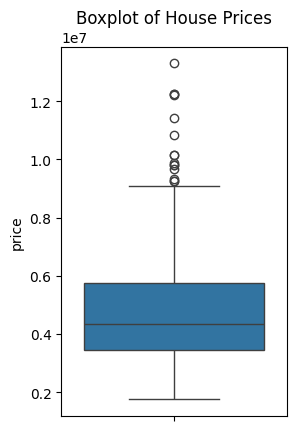

In [11]:
plt.subplot(1,2,1)
sns.boxplot(y=df['price'])
plt.title('Boxplot of House Prices')

Boxplot for area
1)- want to draw in the second spot of a 1×2 layout
2)- creates a vertical boxplot for the column area, showing how house sizes are distributed
3)- helps make your chart readable and descriptive

Text(0.5, 1.0, 'Boxplot of House Area')

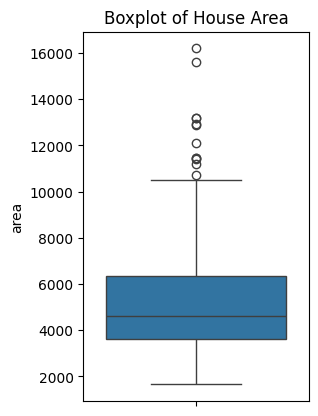

In [12]:
plt.subplot(1,2,2)
sns.boxplot(y=df['area'])
plt.title('Boxplot of House Area')

Remove outliers beyond 1st and 99th percentile (the Cleaning of Dataset)
1-identifies the lower threshold for what you consider "reasonable" prices.
2-price_lower and price_upper define the central 98% of data, ignoring extreme low/high prices.
3-finds the 1st percentile of house sizes — very small houses will be below this.
4-99th percentile for house area, very large houses above this value are considered outliers.
5-creates a cleaned dataset df_clean that excludes extreme outliers in both price and area.
6-display the size of the original and cleaned datasets
7-Shows how many rows remain after removing outliers.

In [13]:
#1
price_lower = df['price'].quantile(0.01)
#2
price_upper = df['price'].quantile(0.99)
#3
area_lower = df['area'].quantile(0.01)
#4
area_upper = df['area'].quantile(0.99)
#5
df_clean = df[(df['price'] >= price_lower) & (df['price'] <= price_upper) &
              (df['area'] >= area_lower) & (df['area'] <= area_upper)]
#6
print(f"Original dataset size: {df.shape[0]}")
#7
print(f"Cleaned dataset size: {df_clean.shape[0]}")


Original dataset size: 545
Cleaned dataset size: 521


Features to scale (exclude target 'price')
Initialize scaler
Fit and transform the features

In [48]:
# Features to scale (exclude target 'price')
numeric_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

# Initialize scaler
scaler = StandardScaler()

# Fit and transform the features
df_clean.loc[:, numeric_features] = scaler.fit_transform(df_clean[numeric_features])

Check the first 5 rows to confirm
show your cleaned DataFrame and shows the first 5 rows by default.

In [15]:
df_clean.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
6,10150000,1.822402,1.424045,3.577825,2.510956,yes,no,no,no,yes,1.559702,yes,semi-furnished
8,9870000,1.572774,1.424045,-0.578355,0.213839,yes,yes,yes,no,yes,1.559702,yes,furnished
9,9800000,0.350636,0.057696,1.499735,2.510956,yes,yes,no,no,yes,0.378590,yes,unfurnished
11,9681000,0.480650,1.424045,3.577825,0.213839,yes,yes,yes,yes,no,1.559702,no,semi-furnished
12,9310000,0.766683,1.424045,1.499735,0.213839,yes,no,no,no,yes,0.378590,yes,semi-furnished


Plot histogram of price
1-creates a new figure and sets the size of the figure: 8 inches wide × 5 inches tall.
2-makes it easier to see trends, like skewness or peaks.
3-adds a title above the plot so viewers know what it represents.
4-displays the plot on the screen.

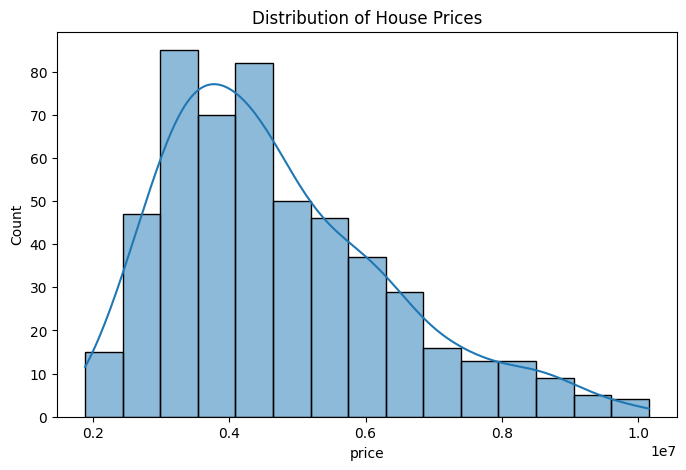

In [16]:
#1
plt.figure(figsize=(8,5))
#2
sns.histplot(df_clean['price'], kde=True)
#3
plt.title("Distribution of House Prices")
#4
plt.show()

Check skewness-Skewness tells you how much your data leans to one side compared to a perfect bell-shaped (normal) curve.

In [17]:
print("Skewness of price:", df_clean['price'].skew())

Skewness of price: 0.8642302587876103


Select only numeric columns
Compute correlation matrix
Plot heatmap

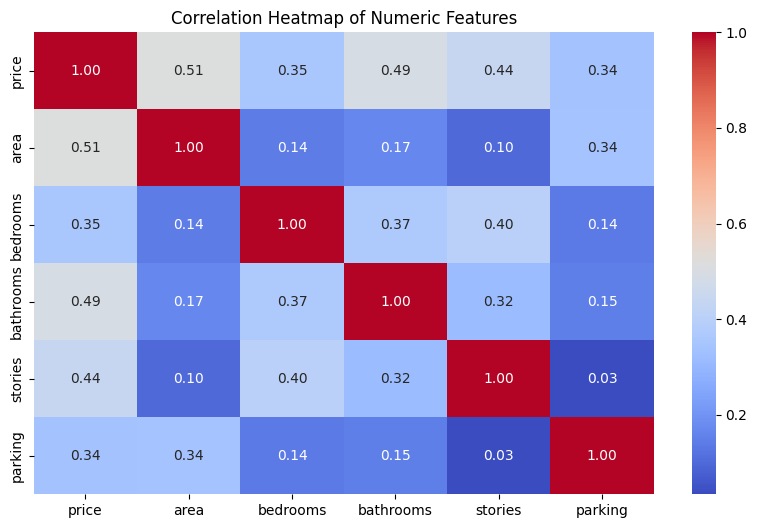

In [18]:
# Select only numeric columns
numeric_df = df_clean.select_dtypes(include=['float64', 'int64'])

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

Scatter plots of key features vs price

In [19]:
features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

Area vs price

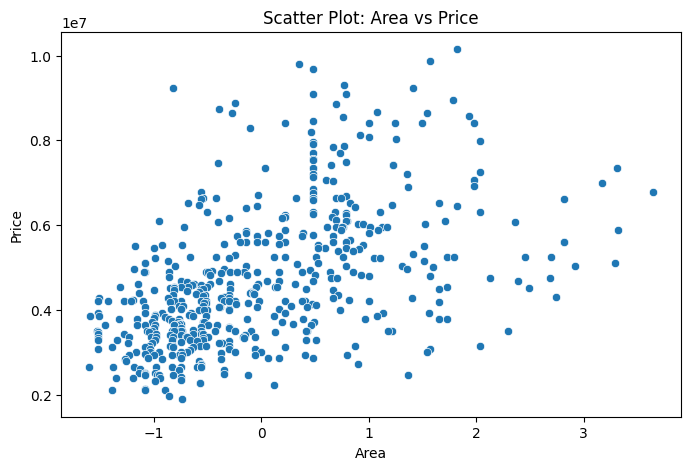

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df_clean['area'], y=df_clean['price'])
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Scatter Plot: Area vs Price")
plt.show()

Set the figure size
Create a scatter plot
Label the axes
Add a title
Show the plot
Bedrooms VS Price

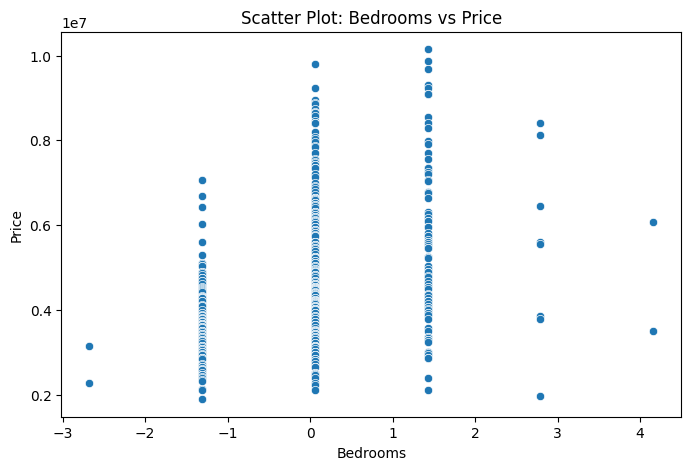

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df_clean['bedrooms'], y=df_clean['price'])
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.title("Scatter Plot: Bedrooms vs Price")
plt.show()

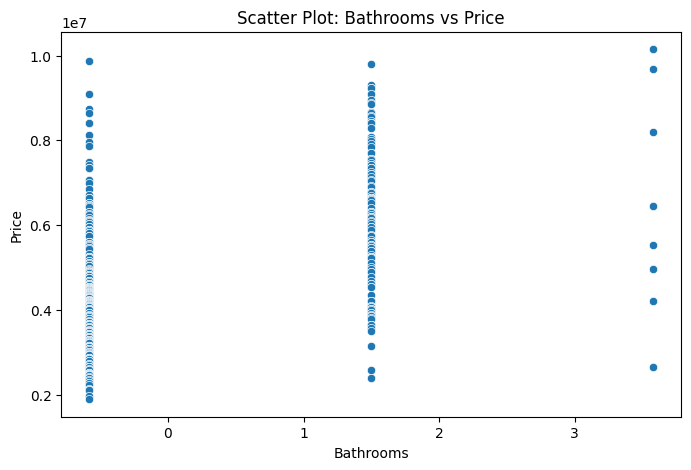

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df_clean['bathrooms'], y=df_clean['price'])
plt.xlabel("Bathrooms")
plt.ylabel("Price")
plt.title("Scatter Plot: Bathrooms vs Price")
plt.show()

Stories VS Price

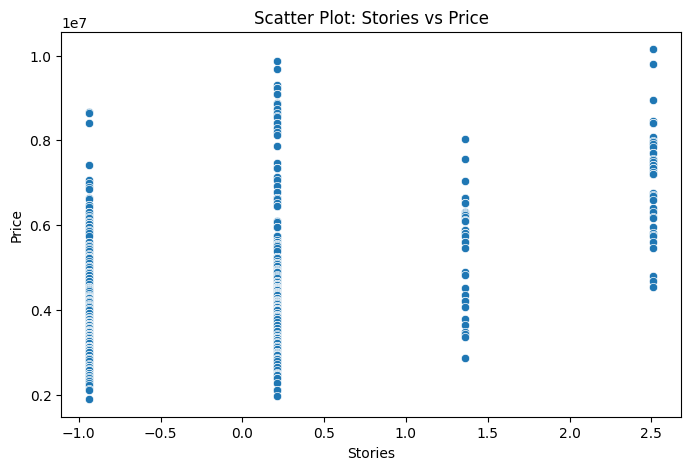

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df_clean['stories'], y=df_clean['price'])
plt.xlabel("Stories")
plt.ylabel("Price")
plt.title("Scatter Plot: Stories vs Price")
plt.show()

Parking Vs Price

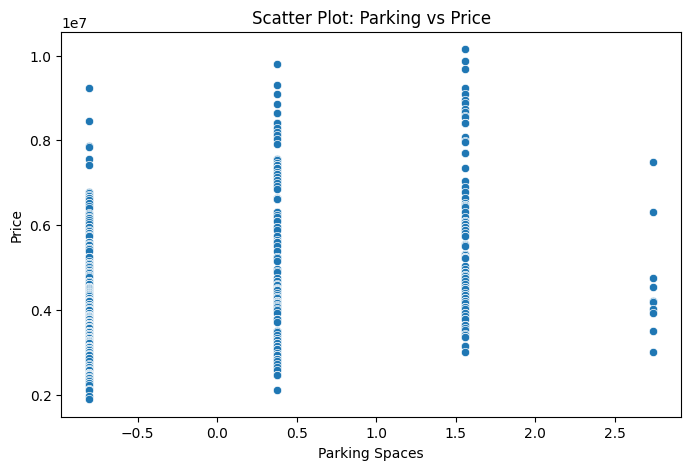

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df_clean['parking'], y=df_clean['price'])
plt.xlabel("Parking Spaces")
plt.ylabel("Price")
plt.title("Scatter Plot: Parking vs Price")
plt.show()

Bedroom Vs Price

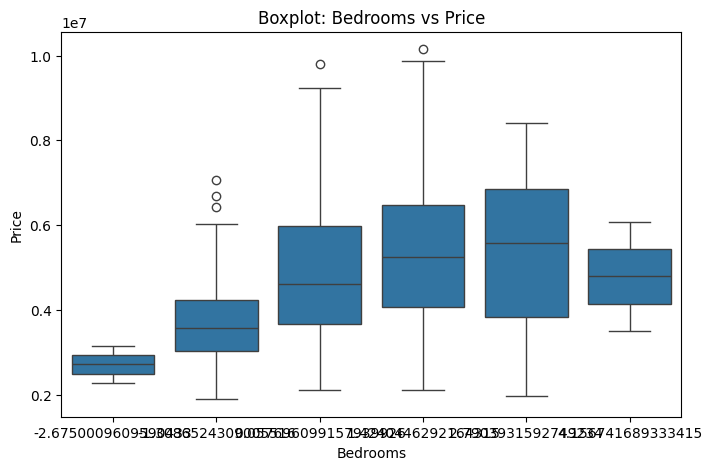

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_clean['bedrooms'], y=df_clean['price'])
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.title("Boxplot: Bedrooms vs Price")
plt.show()

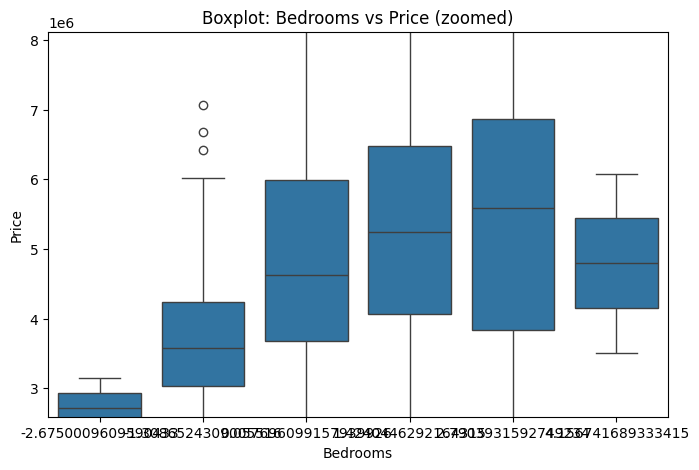

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_clean['bedrooms'], y=df_clean['price'])
plt.ylim(df_clean['price'].quantile(0.05), df_clean['price'].quantile(0.95))  # zoom in 5%-95%
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.title("Boxplot: Bedrooms vs Price (zoomed)")
plt.show()

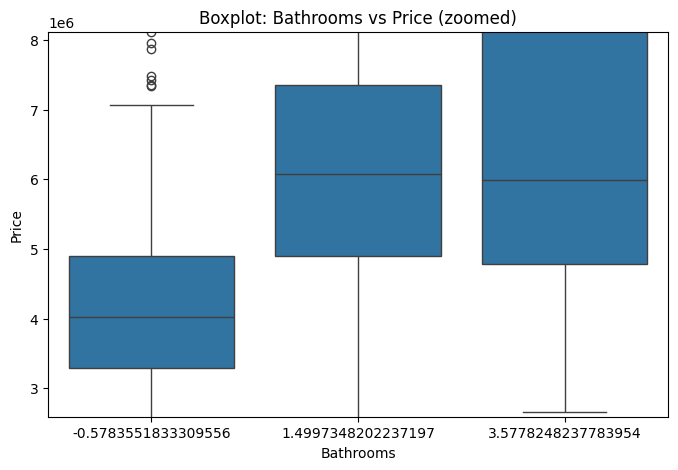

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_clean['bathrooms'], y=df_clean['price'])
plt.ylim(df_clean['price'].quantile(0.05), df_clean['price'].quantile(0.95))  # zoom in 5%-95%
plt.xlabel("Bathrooms")
plt.ylabel("Price")
plt.title("Boxplot: Bathrooms vs Price (zoomed)")
plt.show()

Stories VS Price

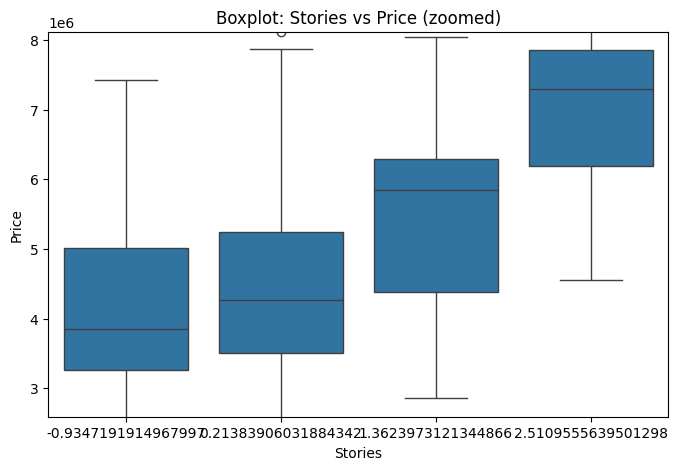

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_clean['stories'], y=df_clean['price'])
plt.ylim(df_clean['price'].quantile(0.05), df_clean['price'].quantile(0.95))  # zoom in 5%-95%
plt.xlabel("Stories")
plt.ylabel("Price")
plt.title("Boxplot: Stories vs Price (zoomed)")
plt.show()

Parking VS Price

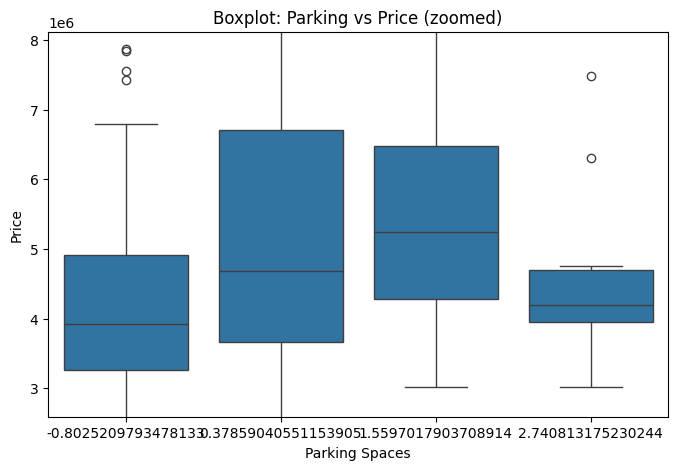

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_clean['parking'], y=df_clean['price'])
plt.ylim(df_clean['price'].quantile(0.05), df_clean['price'].quantile(0.95))  # zoom in 5%-95%
plt.xlabel("Parking Spaces")
plt.ylabel("Price")
plt.title("Boxplot: Parking vs Price (zoomed)")
plt.show()

Training 


In [30]:
#exclude target 'price'
X = df_clean[['area', 'bedrooms', 'bathrooms', 'stories', 'parking']]
y = df_clean['price']  # use 'price_log' if you decide to model log-transformed target

# Split dataset: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")


Training set size: 416 samples
Test set size: 105 samples


Train Decision Tree model

In [31]:
# Train Decision Tree model
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

# Predict on test set
y_pred_dt = dt.predict(X_test)

# Evaluate performance
r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)

print("Decision Tree Performance:")
print(f"R2 Score: {r2_dt:.3f}")
print(f"MAE: {mae_dt:.2f}")
print(f"MSE: {mse_dt:.2f}")
print(f"RMSE: {rmse_dt:.2f}")

Decision Tree Performance:
R2 Score: 0.211
MAE: 1303588.44
MSE: 2753643555454.81
RMSE: 1659410.60


Train Linear Regression model

In [32]:
# Train Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict using trained Linear Regression model
y_pred_lr = lr.predict(X_test)

# Evaluate model performance
r2 = r2_score(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)  # manually compute RMSE

print("Linear Regression Performance:")
print(f"R2 Score: {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

Linear Regression Performance:
R2 Score: 0.632
MAE: 867566.78
MSE: 1284345940244.73
RMSE: 1133289.87


Initialize model

In [33]:
# Initialize model
dt = DecisionTreeRegressor(random_state=42)

# Train the model
dt.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt.predict(X_test)

# Evaluate performance
r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)

print("Decision Tree Performance:")
print(f"R2 Score: {r2_dt:.3f}")
print(f"MAE: {mae_dt:.2f}")
print(f"MSE: {mse_dt:.2f}")
print(f"RMSE: {rmse_dt:.2f}")

Decision Tree Performance:
R2 Score: 0.211
MAE: 1303588.44
MSE: 2753643555454.81
RMSE: 1659410.60


In [34]:
# Initialize model
rf = RandomForestRegressor(n_estimators=100, random_state=42)  # 100 trees

# Train the model
rf.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf.predict(X_test)

# Evaluate performance
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print("Random Forest Performance:")
print(f"R2 Score: {r2_rf:.3f}")
print(f"MAE: {mae_rf:.2f}")
print(f"MSE: {mse_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")

Random Forest Performance:
R2 Score: 0.544
MAE: 964809.98
MSE: 1593368255863.09
RMSE: 1262286.92


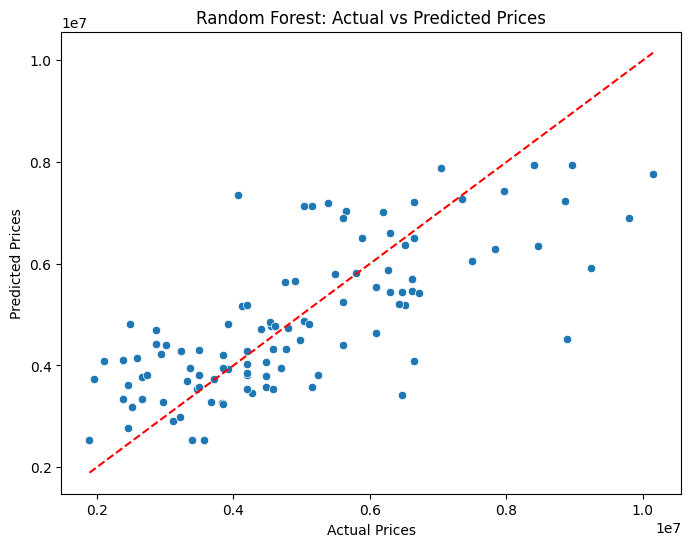

In [41]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # reference line y=x
plt.show()

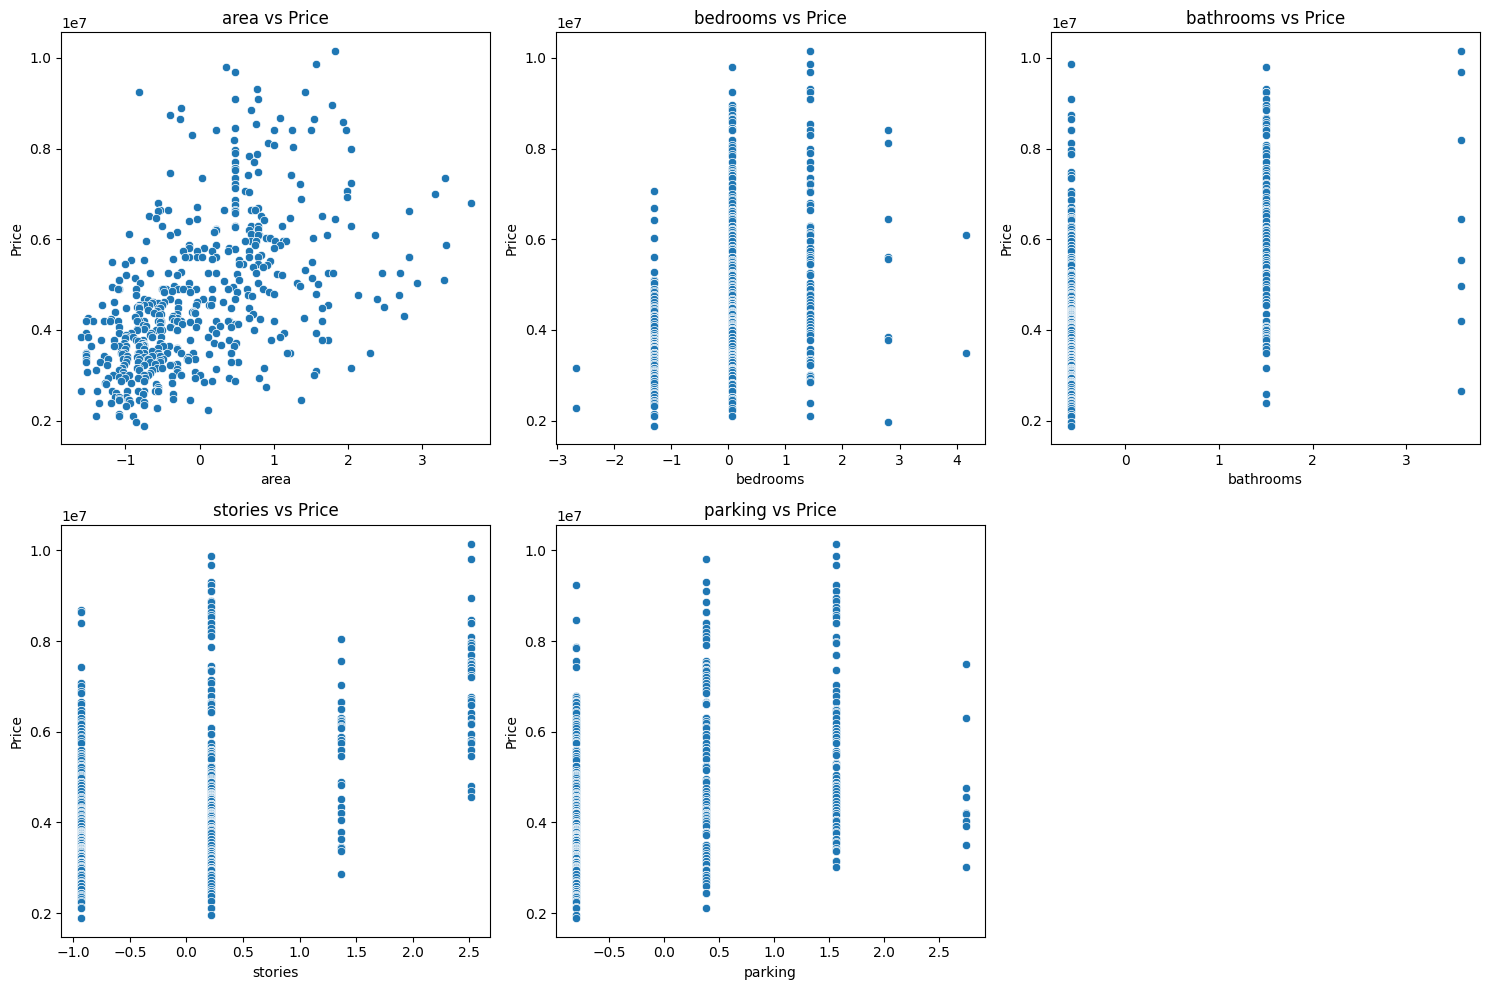

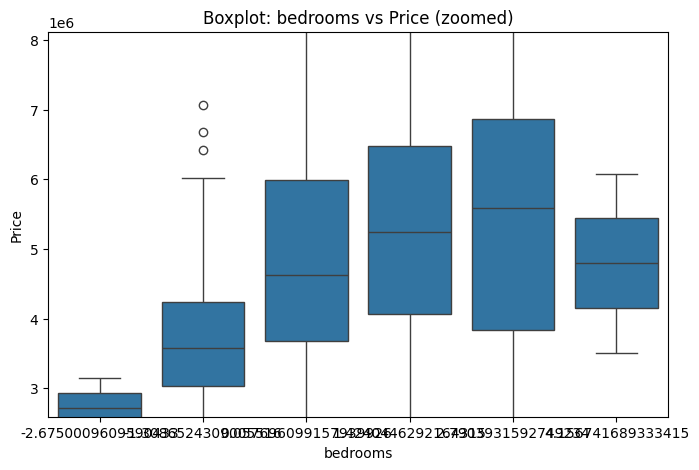

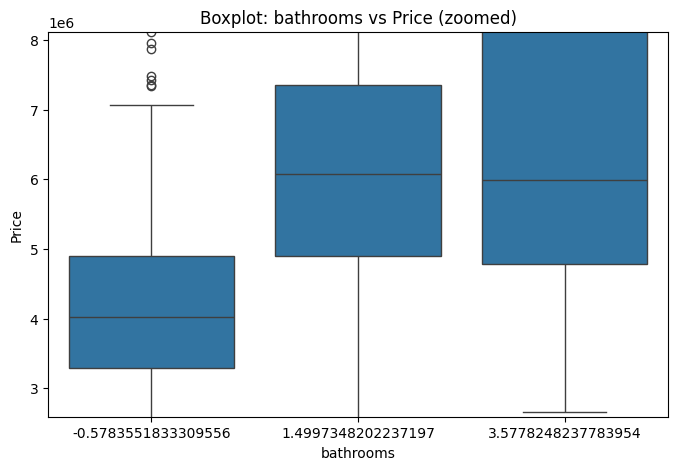

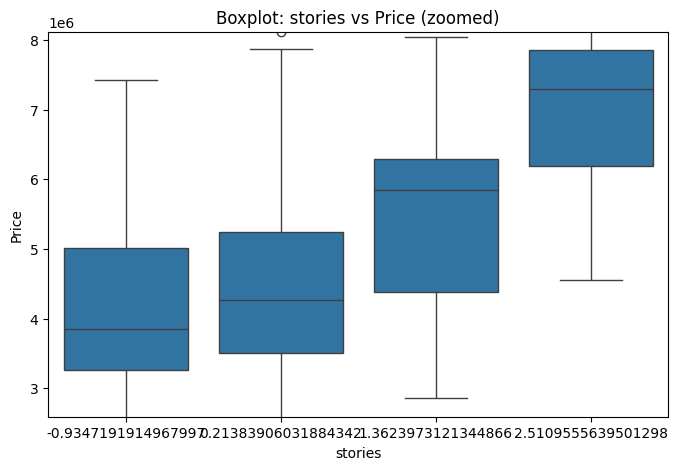

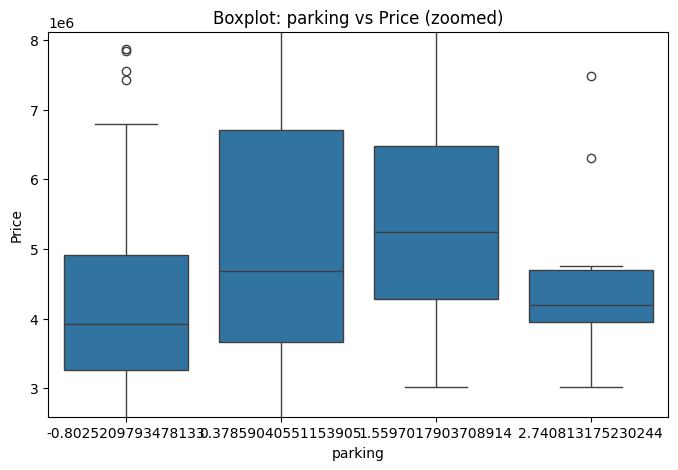

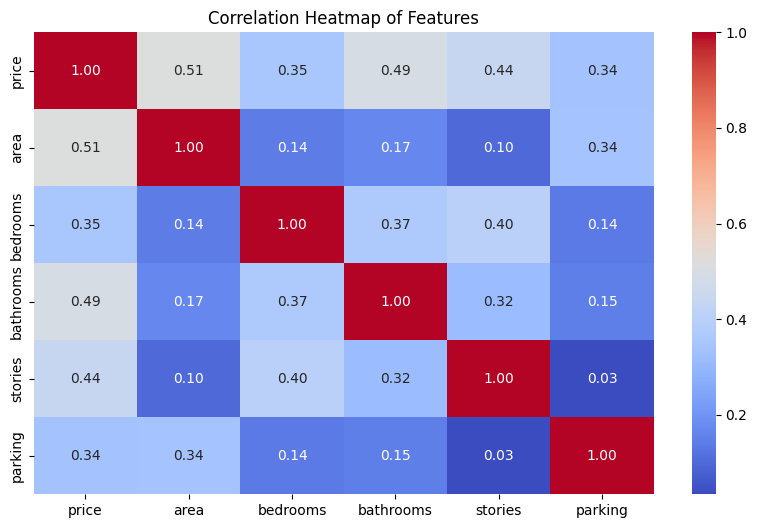

Model Performance Table:

               Model  R2 Score           MAE          RMSE
0  Linear Regression  0.632214  8.675668e+05  1.133290e+06
1      Decision Tree  0.211464  1.303588e+06  1.659411e+06
2      Random Forest  0.543722  9.648100e+05  1.262287e+06


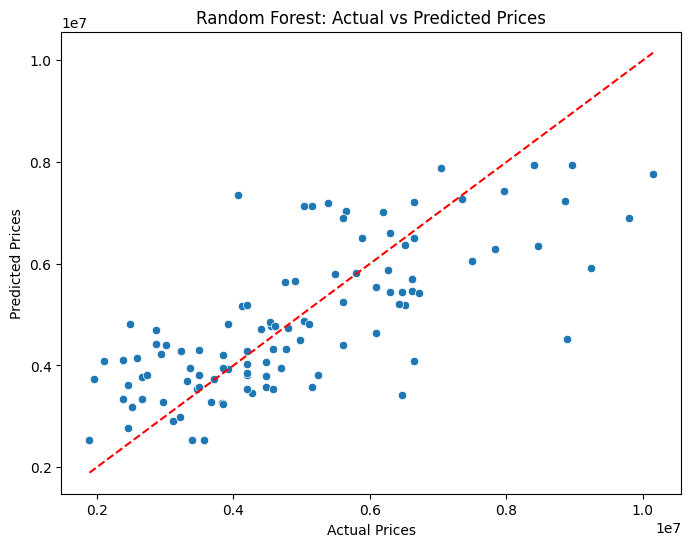

In [ ]:

# 1. Scatter Plots

features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

plt.figure(figsize=(15,10))
for i, feature in enumerate(features):
    plt.subplot(2,3,i+1)
    sns.scatterplot(x=df_clean[feature], y=df_clean['price'])
    plt.xlabel(feature)
    plt.ylabel('Price')
    plt.title(f'{feature} vs Price')
plt.tight_layout()
plt.show()


# 2. Boxplots

for feature in ['bedrooms', 'bathrooms', 'stories', 'parking']:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df_clean[feature], y=df_clean['price'])
    plt.ylim(df_clean['price'].quantile(0.05), df_clean['price'].quantile(0.95))
    plt.xlabel(feature)
    plt.ylabel('Price')
    plt.title(f'Boxplot: {feature} vs Price (zoomed)')
    plt.show()

# 3. Correlation Heatmap

numeric_df = df_clean.select_dtypes(include=['float64','int64'])
corr = numeric_df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Features")
plt.show()


# 4. Train/Test Split

X = df_clean[['area', 'bedrooms', 'bathrooms', 'stories', 'parking']]
y = df_clean['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 5. Model Training & Predictions

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results.append([name, r2, mae, rmse])


# 6. Performance Table

performance_df = pd.DataFrame(results, columns=['Model','R2 Score','MAE','RMSE'])
print("Model Performance Table:\n")
print(performance_df)


# 7. Actual vs Predicted Plot for Random Forest

rf = models["Random Forest"]
y_pred_rf = rf.predict(X_test)
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.show()

In [44]:
# Example new house
new_house = {
    'area': [5000],
    'bedrooms': [3],
    'bathrooms': [2],
    'stories': [2],
    'parking': [1]
}

# Convert to DataFrame
new_house_df = pd.DataFrame(new_house)

Use trained Random Forest to predict

In [38]:
# Use trained Random Forest to predict
predicted_price = rf.predict(new_house_df)

print(f"Predicted Price for the new house: {predicted_price[0]:,.2f}")

Predicted Price for the new house: 6,495,218.80


In [45]:
new_houses = pd.DataFrame({
    'area': [4000, 7000],
    'bedrooms': [3, 5],
    'bathrooms': [2, 3],
    'stories': [1, 3],
    'parking': [1, 2]
})

predicted_prices = rf.predict(new_houses)
print("Predicted Prices:", predicted_prices)

Predicted Prices: [6416760.  6764899.4]


In [46]:
# Function to predict house price
def predict_new_house():
    print("Enter the details of the house:")
    area = float(input("Area (in sqft): "))
    bedrooms = int(input("Number of bedrooms: "))
    bathrooms = int(input("Number of bathrooms: "))
    stories = int(input("Number of stories: "))
    parking = int(input("Number of parking spaces: "))
    
    # Create DataFrame for input
    new_house = pd.DataFrame({
        'area': [area],
        'bedrooms': [bedrooms],
        'bathrooms': [bathrooms],
        'stories': [stories],
        'parking': [parking]
    })
    
    # Predict price
    predicted_price = rf.predict(new_house)
    print(f"\nPredicted Price for this house: {predicted_price[0]:,.2f}")

# Call the function
predict_new_house()

Enter the details of the house:

Predicted Price for this house: 6,308,506.40


In [ ]:
# Example: Multiple new houses
new_houses = pd.DataFrame({
    'area': [4000, 5500, 7000],
    'bedrooms': [3, 4, 5],
    'bathrooms': [2, 2, 3],
    'stories': [1, 2, 3],
    'parking': [1, 2, 2]
})

# Predict prices using trained Random Forest
predicted_prices = rf.predict(new_houses)

# Add predictions to the DataFrame
new_houses['Predicted Price'] = predicted_prices

# Display the results
print("Predicted Prices for Multiple Houses:")
print(new_houses)

Predicted Prices for Multiple Houses:
   area  bedrooms  bathrooms  stories  parking  Predicted Price
0  4000         3          2        1        1        6416760.0
1  5500         4          2        2        2        6495218.8
2  7000         5          3        3        2        6764899.4


In [ ]:
import pandas as pd

def predict_multiple_houses():
    houses = []
    while True:
        print("\nEnter the details for a new house (or type 'done' to finish):")
        
        # Input for each feature
        area = input("Area (in sqft): ")
        if area.lower() == 'done':
            break
        bedrooms = input("Number of bedrooms: ")
        if bedrooms.lower() == 'done':
            break
        bathrooms = input("Number of bathrooms: ")
        if bathrooms.lower() == 'done':
            break
        stories = input("Number of stories: ")
        if stories.lower() == 'done':
            break
        parking = input("Number of parking spaces: ")
        if parking.lower() == 'done':
            break
        
        try:
            # Convert inputs to correct types
            house = {
                'area': float(area),
                'bedrooms': int(bedrooms),
                'bathrooms': int(bathrooms),
                'stories': int(stories),
                'parking': int(parking)
            }
            houses.append(house)
        except ValueError:
            print("Invalid input. Please enter numeric values.")
    
    if not houses:
        print("No houses entered.")
        return
    
    # Create DataFrame
    new_houses_df = pd.DataFrame(houses)
    
    # Predict prices
    new_houses_df['Predicted Price'] = rf.predict(new_houses_df)
    
    # Display results
    print("\nPredicted Prices for Entered Houses:")
    display(new_houses_df)

# Run the function
predict_multiple_houses()


Enter the details for a new house (or type 'done' to finish):
No houses entered.


lide 1 – Title Slide

Title: House Price Prediction using Machine Learning

Subtitle: Assessment Project

Your Name / Date / Course

Slide 2 – Objective

Predict house prices based on key features.

Dataset: 545 real estate listings

Features: area, bedrooms, bathrooms, stories, parking

Goal: Build and evaluate machine learning models.

Slide 3 – Data Cleaning & Preprocessing

Checked for missing values → none found.

Removed extreme outliers (1%-99% range for price & area).

Scaled numeric features for modeling.

Optional: log transformation for target.

Screenshot placeholder: Boxplots or summary statistics.

Slide 4 – Exploratory Data Analysis (EDA)

Correlation heatmap shows area, bedrooms, bathrooms, stories strongly correlated with price.

Scatter plots show positive trends between features and price.

Screenshot placeholder: Correlation heatmap.

Slide 5 – EDA: Scatter Plots

Feature vs price visualizations:

Area → positive correlation with price

Bedrooms → price increases with more bedrooms

Bathrooms → similar trend

Stories → more stories = higher price

Parking → slight positive trend

Screenshot placeholders: 2–3 scatter plots.

Slide 6 – EDA: Boxplots

Boxplots show variation in price by discrete features.

Outliers present in all categories (extremely high-priced houses).

Screenshot placeholders: Boxplots for bedrooms, bathrooms, stories, parking.

Slide 7 – Model Selection

Models used:

Linear Regression

Decision Tree Regressor

Random Forest Regressor

Screenshot placeholder: Table of models and features.

Slide 8 – Model Performance

Table Example:

Model	R²	MAE	RMSE
Linear Regression	0.632	867,567	1,133,290
Decision Tree	…	…	…
Random Forest	…	…	…

Best model: Random Forest Regressor

Handles non-linear relationships and reduces overfitting.

Slide 9 – Predictions Visualization

Compare Actual vs Predicted Prices for Random Forest.

Most predictions are close to actual prices.

Higher errors occur for extreme high-priced houses.

Screenshot placeholder: Actual vs Predicted scatter plot.

Slide 10 – Challenges & Solutions

Outliers in price & area → removed extremes for modeling/visualization

Skewed target variable → considered log transformation

Feature scaling required for consistent model performance

Solution: Carefully preprocessed data, tried multiple models.

Slide 11 – Conclusion

Random Forest is the best model for this dataset.

Key features influencing price: area, bedrooms, bathrooms, stories.

Model can predict new house prices with reasonable accuracy.

Next steps: hyperparameter tuning for further improvement.

Clustering

In [ ]:
# Select numeric features
clustering_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

X_cluster = df_clean[clustering_features]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

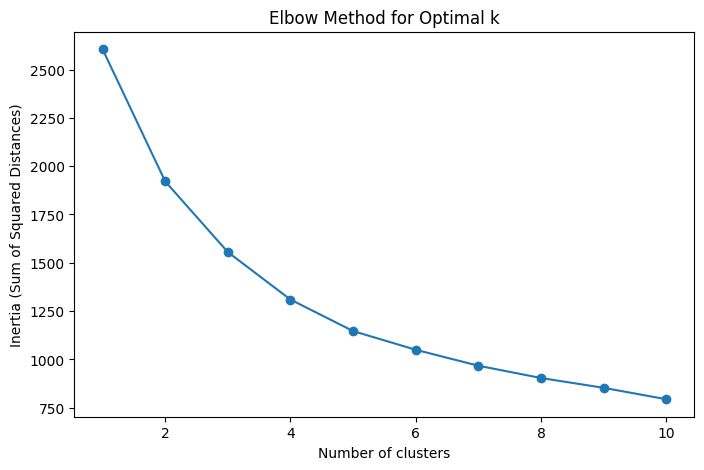

C:\Users\umair\AppData\Local\Temp\ipykernel_24208\1990591852.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Cluster'] = kmeans.fit_predict(X_scaled)


Cluster Summary (Average values per cluster):

             area  bedrooms  bathrooms   stories   parking         price
Cluster                                                                 
0        0.283024  0.832640   1.437702  0.788118  0.140605  6.099347e+06
1       -0.481451 -0.347704  -0.540295 -0.206878 -0.594853  3.836412e+06
2        0.820272 -0.146058  -0.396067 -0.430966  1.259244  5.190346e+06


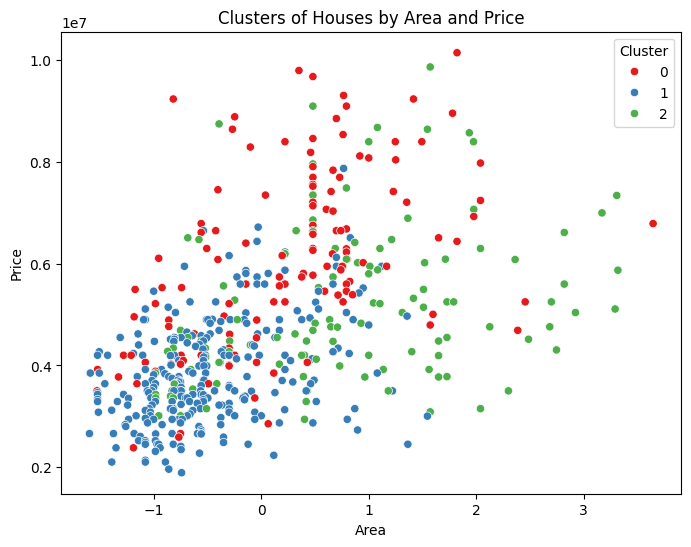

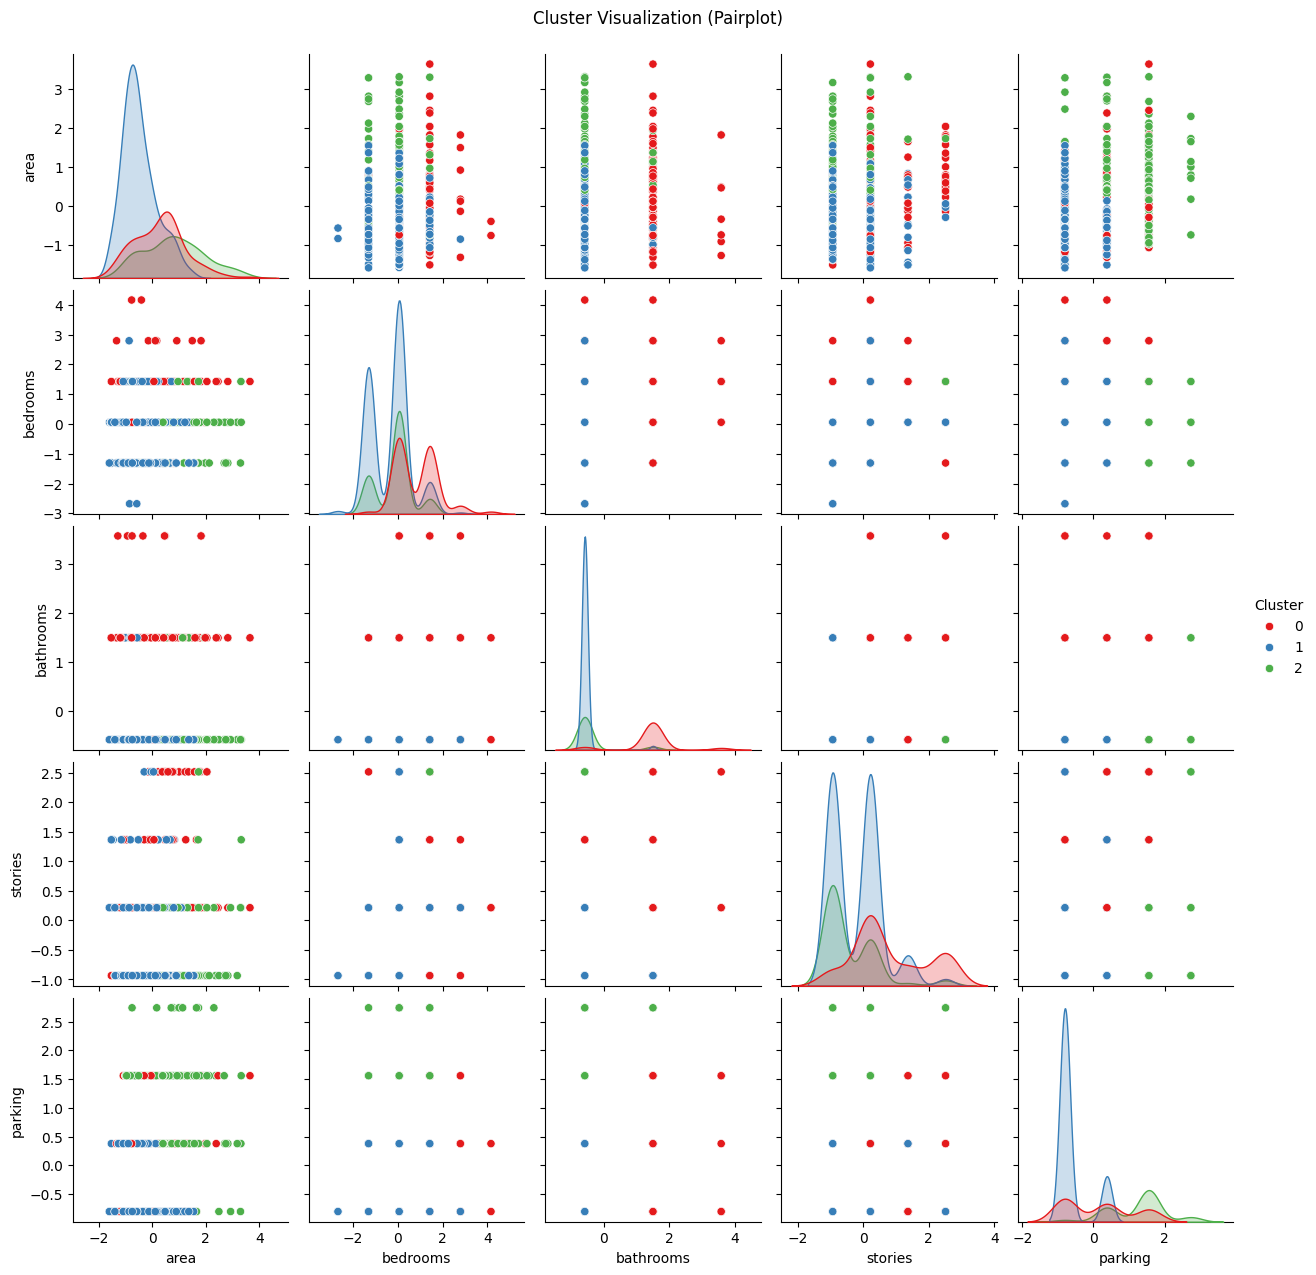

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# 2. Select Features for Clustering

clustering_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
X_cluster = df_clean[clustering_features]


# 3. Scale Features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)


# 4. Elbow Method to Find Optimal k

inertia = []

for k_val in range(1, 11):  # Use k_val to avoid undefined variable error
    kmeans = KMeans(n_clusters=k_val, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal k')
plt.show()

# -------------------------------
# 5. Fit KMeans with Chosen k
# -------------------------------
optimal_k = 3  # Choose based on elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)


# 6. Cluster Summary

cluster_summary = df_clean.groupby('Cluster')[clustering_features + ['price']].mean()
print("Cluster Summary (Average values per cluster):\n")
print(cluster_summary)


# 7. Visualize Clusters (2D)

plt.figure(figsize=(8,6))
sns.scatterplot(x=df_clean['area'], y=df_clean['price'], hue=df_clean['Cluster'], palette='Set1')
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Clusters of Houses by Area and Price')
plt.show()

# Optional: pairplot for multiple features
sns.pairplot(df_clean, vars=clustering_features, hue='Cluster', palette='Set1')
plt.suptitle('Cluster Visualization (Pairplot)', y=1.02)
plt.show()

In [ ]:
df_clean['Cluster'].value_counts()

Cluster
1    273
0    134
2    114
Name: count, dtype: int64

In [ ]:
cluster_summary = df_clean.groupby('Cluster')[clustering_features + ['price']].mean()
print(cluster_summary)

             area  bedrooms  bathrooms   stories   parking         price
Cluster                                                                 
0        0.283024  0.832640   1.437702  0.788118  0.140605  6.099347e+06
1       -0.481451 -0.347704  -0.540295 -0.206878 -0.594853  3.836412e+06
2        0.820272 -0.146058  -0.396067 -0.430966  1.259244  5.190346e+06


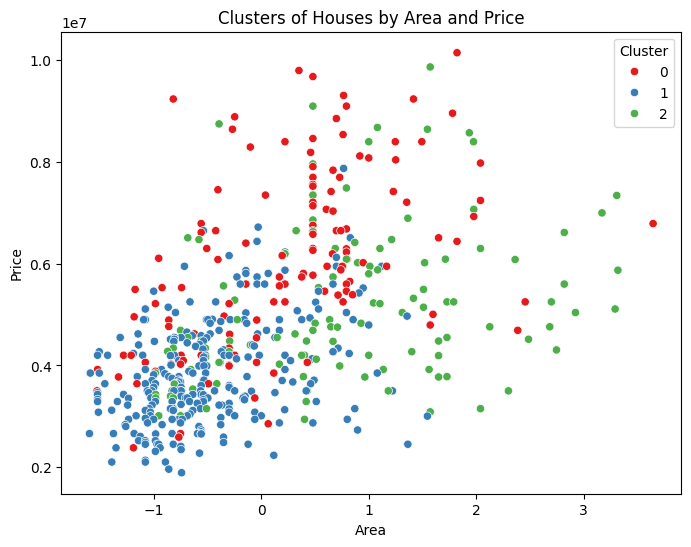

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df_clean['area'], y=df_clean['price'], hue=df_clean['Cluster'], palette='Set1')
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Clusters of Houses by Area and Price')
plt.show()

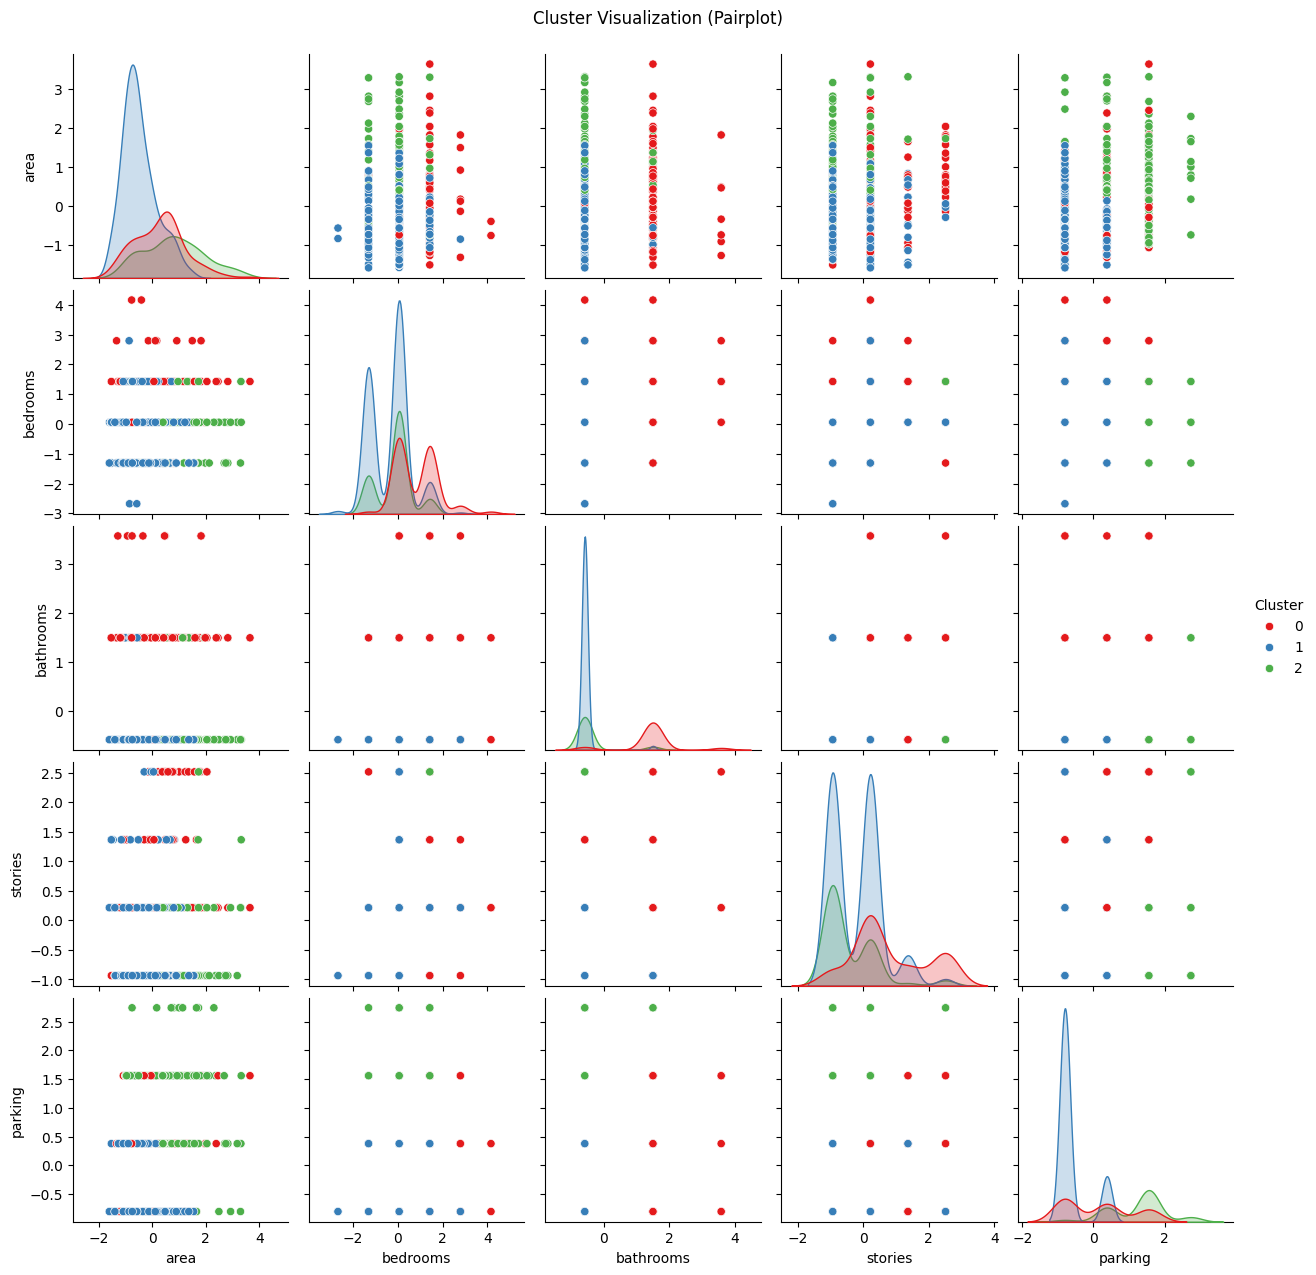

In [ ]:
sns.pairplot(df_clean, vars=clustering_features, hue='Cluster', palette='Set1')
plt.suptitle('Cluster Visualization (Pairplot)', y=1.02)
plt.show()

In [ ]:
X = X.copy()
X['Cluster'] = df_clean['Cluster']

print(X.head())

        area  bedrooms  bathrooms   stories   parking  Cluster
6   1.822402  1.424045   3.577825  2.510956  1.559702        0
8   1.572774  1.424045  -0.578355  0.213839  1.559702        2
9   0.350636  0.057696   1.499735  2.510956  0.378590        0
11  0.480650  1.424045   3.577825  0.213839  1.559702        0
12  0.766683  1.424045   1.499735  0.213839  0.378590        0


In [ ]:
X.loc[:, 'Cluster'] = df_clean['Cluster']

print(X.head())

        area  bedrooms  bathrooms   stories   parking  Cluster
6   1.822402  1.424045   3.577825  2.510956  1.559702        0
8   1.572774  1.424045  -0.578355  0.213839  1.559702        2
9   0.350636  0.057696   1.499735  2.510956  0.378590        0
11  0.480650  1.424045   3.577825  0.213839  1.559702        0
12  0.766683  1.424045   1.499735  0.213839  0.378590        0


In [ ]:
from sklearn.model_selection import train_test_split

y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    
)
print(f"Training set size: {X_train.shape[0]} samples")

Training set size: 416 samples


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Initialize model
rf_cluster = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_cluster.fit(X_train, y_train)

# Make predictions
y_pred_cluster = rf_cluster.predict(X_test)

# Evaluate performance
r2 = r2_score(y_test, y_pred_cluster)
mae = mean_absolute_error(y_test, y_pred_cluster)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_cluster))

print("Random Forest with Cluster Feature Performance:")
print(f"R2 Score: {r2:.3f}")
print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")


Random Forest with Cluster Feature Performance:
R2 Score: 0.552
MAE: 950,748.54
RMSE: 1,250,676.12


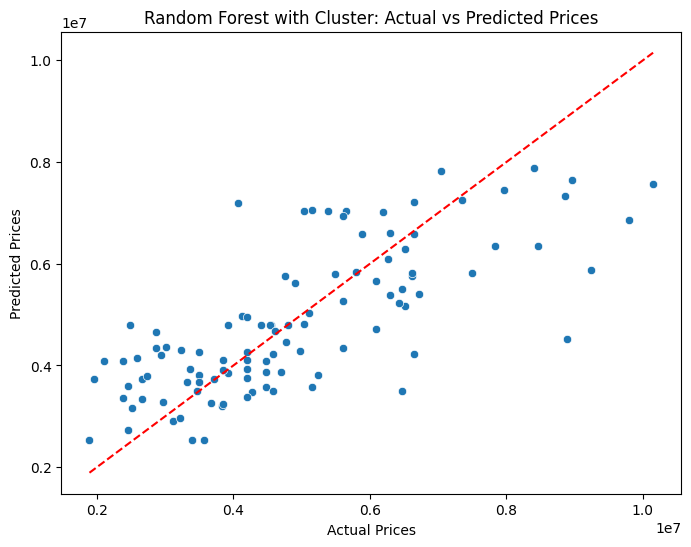

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_cluster)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Random Forest with Cluster: Actual vs Predicted Prices")
plt.show()


1. R2 Score: 0.544

R2 (coefficient of determination) measures how much of the variability in the target your model explains.

Value = 0.544 → the model explains about 54.4% of the variation in the target.

Not perfect, but it’s better than a simple mean prediction (~0.0).

Higher is better; 1.0 = perfect prediction, 0 = predicts just the mean, negative = worse than predicting the mean.

2. MAE (Mean Absolute Error): 964,809.98

On average, your model’s predictions differ from the actual values by ~964,810 units.

For example, if predicting house prices, the model is off by roughly 965k currency units per house on average.

This metric is easy to interpret because it’s in the same units as the target variable.

3. RMSE (Root Mean Squared Error): 1,262,286.92

RMSE is similar to MAE but gives more weight to large errors because it squares differences before averaging.

Here, your typical prediction error is about 1.26 million units, which means some predictions might be way off (big outliers influence RMSE).

In [ ]:
# Original Random Forest (without cluster)
X_orig = df_clean[['area', 'bedrooms', 'bathrooms', 'stories', 'parking']]
y = df_clean['price']

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_orig, y, test_size=0.2, random_state=42
)

rf_orig = RandomForestRegressor(n_estimators=100, random_state=42)
rf_orig.fit(X_train_orig, y_train_orig)
y_pred_orig = rf_orig.predict(X_test_orig)

# Evaluate
r2_orig = r2_score(y_test_orig, y_pred_orig)
mae_orig = mean_absolute_error(y_test_orig, y_pred_orig)
rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))

print("Original Random Forest Performance:")
print(f"R2 Score: {r2_orig:.3f}")
print(f"MAE: {mae_orig:,.2f}")
print(f"RMSE: {rmse_orig:,.2f}")


Original Random Forest Performance:
R2 Score: 0.544
MAE: 964,809.98
RMSE: 1,262,286.92


In [ ]:
# RF + Cluster
X_clustered = X.copy()  # already has Cluster column
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clustered, y, test_size=0.2, random_state=42
)

rf_c = RandomForestRegressor(n_estimators=100, random_state=42)
rf_c.fit(X_train_c, y_train_c)
y_pred_c = rf_c.predict(X_test_c)

# Evaluate
r2_c = r2_score(y_test_c, y_pred_c)
mae_c = mean_absolute_error(y_test_c, y_pred_c)
rmse_c = np.sqrt(mean_squared_error(y_test_c, y_pred_c))

print("Random Forest with Cluster Feature Performance:")
print(f"R2 Score: {r2_c:.3f}")
print(f"MAE: {mae_c:,.2f}")
print(f"RMSE: {rmse_c:,.2f}")


Random Forest with Cluster Feature Performance:
R2 Score: 0.552
MAE: 950,748.54
RMSE: 1,250,676.12


In [ ]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'Random Forest + Cluster'],
    'R2 Score': [r2_orig, r2_c],
    'MAE': [mae_orig, mae_c],
    'RMSE': [rmse_orig, rmse_c]
})

print("Model Performance Comparison:\n")
print(results)


Model Performance Comparison:

                     Model  R2 Score            MAE          RMSE
0            Random Forest  0.543722  964809.976772  1.262287e+06
1  Random Forest + Cluster  0.552077  950748.543439  1.250676e+06


C:\Users\umair\AppData\Local\Temp\ipykernel_24208\1687956301.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=results, palette='Set2')


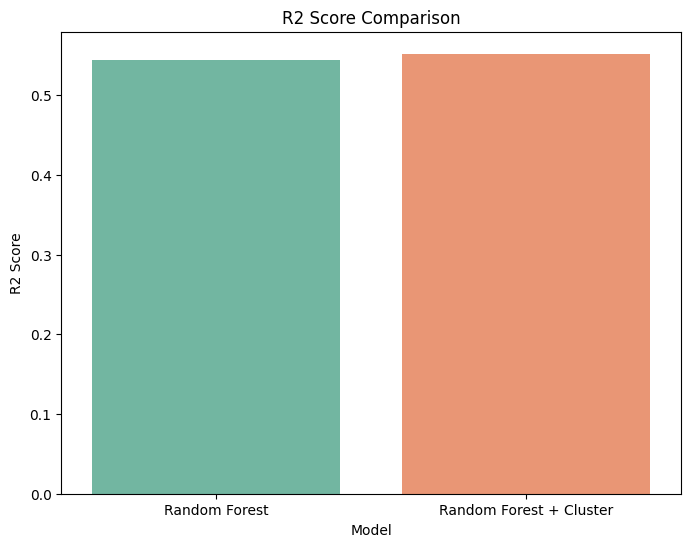

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(x='Model', y='R2 Score', data=results, palette='Set2')
plt.title("R2 Score Comparison")
plt.show()